In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import os
import operator
import time
import matplotlib.pyplot as plt
import tensorflow as tf
from sklearn import datasets  
from sklearn.ensemble import RandomForestClassifier
from numpy import argmax
from sklearn.model_selection import train_test_split
from sklearn import metrics  
from sklearn.tree import plot_tree
from sklearn import tree
from sklearn.model_selection import GridSearchCV
from scipy.stats import randint
from sklearn.model_selection import RandomizedSearchCV

import warnings
warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", None)

In [2]:
#Create a path to where your data is stored.
path = r'/Users/april/Machine Learning'

In [3]:
#Create a path to where your data is stored.
path2 = r'/Users/april/Machine Learning/Datasets'

In [4]:
# Export weather data
X = pd.read_csv(os.path.join(path, 'weather_clean.csv'), index_col =False)

In [5]:
#Read in the pleasant weather data.
pleasantweather = pd.read_csv(os.path.join(path2, 'Supervised','Dataset-Answers-Weather_Prediction_Pleasant_Weather.csv'))
pleasantweather

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
0,19600101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
1,19600102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
2,19600103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
3,19600104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
4,19600105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
22945,20221027,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22946,20221028,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22947,20221029,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
22948,20221030,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


## Data Wrangling

In [6]:
# Reduce observations dataset to 2010's

dfdecade = X[(X['DATE'].astype(str).str[:4] >= '2010') & (X['DATE'].astype(str).str[:4] <= '2019')]
dfdecade

,DATE,MONTH,BASEL_cloud_cover,BASEL_humidity,BASEL_pressure,BASEL_global_radiation,BASEL_precipitation,BASEL_sunshine,BASEL_temp_mean,BASEL_temp_min,BASEL_temp_max,BELGRADE_cloud_cover,BELGRADE_humidity,BELGRADE_pressure,BELGRADE_global_radiation,BELGRADE_precipitation,BELGRADE_sunshine,BELGRADE_temp_mean,BELGRADE_temp_min,BELGRADE_temp_max,BUDAPEST_cloud_cover,BUDAPEST_humidity,BUDAPEST_pressure,BUDAPEST_global_radiation,BUDAPEST_precipitation,BUDAPEST_sunshine,BUDAPEST_temp_mean,BUDAPEST_temp_min,BUDAPEST_temp_max,DEBILT_cloud_cover,DEBILT_humidity,DEBILT_pressure,DEBILT_global_radiation,DEBILT_precipitation,DEBILT_sunshine,DEBILT_temp_mean,DEBILT_temp_min,DEBILT_temp_max,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max,HEATHROW_cloud_cover,HEATHROW_humidity,HEATHROW_pressure,HEATHROW_global_radiation,HEATHROW_precipitation,HEATHROW_sunshine,HEATHROW_temp_mean,HEATHROW_temp_min,HEATHROW_temp_max,KASSEL_cloud_cover,KASSEL_humidity,KASSEL_pressure,KASSEL_global_radiation,KASSEL_precipitation,KASSEL_sunshine,KASSEL_temp_mean,KASSEL_temp_min,KASSEL_temp_max,LJUBLJANA_cloud_cover,LJUBLJANA_humidity,LJUBLJANA_pressure,LJUBLJANA_global_radiation,LJUBLJANA_precipitation,LJUBLJANA_sunshine,LJUBLJANA_temp_mean,LJUBLJANA_temp_min,LJUBLJANA_temp_max,MAASTRICHT_cloud_cover,MAASTRICHT_humidity,MAASTRICHT_pressure,MAASTRICHT_global_radiation,MAASTRICHT_precipitation,MAASTRICHT_sunshine,MAASTRICHT_temp_mean,MAASTRICHT_temp_min,MAASTRICHT_temp_max,MADRID_cloud_cover,MADRID_humidity,MADRID_pressure,MADRID_global_radiation,MADRID_precipitation,MADRID_sunshine,MADRID_temp_mean,MADRID_temp_min,MADRID_temp_max,MUNCHENB_cloud_cover,MUNCHENB_humidity,MUNCHENB_pressure,MUNCHENB_global_radiation,MUNCHENB_precipitation,MUNCHENB_sunshine,MUNCHENB_temp_mean,MUNCHENB_temp_min,MUNCHENB_temp_max,OSLO_cloud_cover,OSLO_humidity,OSLO_pressure,OSLO_global_radiation,OSLO_precipitation,OSLO_sunshine,OSLO_temp_mean,OSLO_temp_min,OSLO_temp_max,SONNBLICK_cloud_cover,SONNBLICK_humidity,SONNBLICK_pressure,SONNBLICK_global_radiation,SONNBLICK_precipitation,SONNBLICK_sunshine,SONNBLICK_temp_mean,SONNBLICK_temp_min,SONNBLICK_temp_max,STOCKHOLM_cloud_cover,STOCKHOLM_humidity,STOCKHOLM_pressure,STOCKHOLM_global_radiation,STOCKHOLM_precipitation,STOCKHOLM_sunshine,STOCKHOLM_temp_mean,STOCKHOLM_temp_min,STOCKHOLM_temp_max,VALENTIA_cloud_cover,VALENTIA_humidity,VALENTIA_pressure,VALENTIA_global_radiation,VALENTIA_precipitation,VALENTIA_sunshine,VALENTIA_temp_mean,VALENTIA_temp_min,VALENTIA_temp_max
18263,20100101,-1.599964,1.076130,1.548792,-3.288021,-1.251420,0.676766,-1.065304,-1.017527,-0.998933,-1.177051,0.652846,1.190400,-3.430229,-1.000382,4.786143,-0.593919,-0.313229,-0.015684,-0.400906,0.733328,-0.010098,-0.005876,-1.267237,-0.344984,-1.170378,-0.793315,-0.584533,-0.860946,-0.673053,-0.354910,-1.293622,-0.860780,-0.498787,-0.048655,-1.838979,-2.102599,-1.822356,1.232526,1.143615,-1.928262,-1.157575,-0.449820,-1.014908,-1.740492,-1.529682,-1.936556,-1.623672,-0.012023,-0.936526,-0.781415,-0.436400,0.538458,-1.678883,-1.466534,-1.541696,1.205492,1.463623,-2.153687,-1.267817,0.017139,-1.074723,-1.733389,-1.402013,-1.872466,1.205492,1.632150,-3.214028,-1.286850,0.088387,-1.149211,-0.462649,-0.117925,-0.826749,0.703568,0.982870,-1.635203,-1.163075,-0.451686,-1.057726,-1.822435,-2.053337,-1.960145,0.484733,1.322744,-0.915829,-1.496755,-0.289516,-1.184150,-1.257862,-1.001951,-1.415676,0.731180,1.183399,-0.486335,-1.244144,0.292068,-1.098059,-0.743302,-0.644217,-0.951273,0.682401,0.165114,-0.049848,-1.067870,0.045478,-1.018677,-1.715566,-1.537028,-1.641071,-0.428835,0.274900,-0.486335,-1.038620,0.116782,0.199980,-0.680084,-0.599621,-0.751687,0.291952,0.165114,-0.174574,-1.008328,-0.223582,-0.712731,-1.859060,-1.759336,-1.947133,-2.897272,-0.363113,-0.199725,-0.829990,-0.490810,0.762612,-2.711082,-2.596636,-2.448957
18264,20100102

In [7]:
# Reduce pleasantweather dataset to 2010's

pleasantweather_decade = pleasantweather[(pleasantweather['DATE'].astype(str).str[:4] >= '2010') & (pleasantweather['DATE'].astype(str).str[:4] <= '2019')]
pleasantweather_decade

,DATE,BASEL_pleasant_weather,BELGRADE_pleasant_weather,BUDAPEST_pleasant_weather,DEBILT_pleasant_weather,DUSSELDORF_pleasant_weather,HEATHROW_pleasant_weather,KASSEL_pleasant_weather,LJUBLJANA_pleasant_weather,MAASTRICHT_pleasant_weather,MADRID_pleasant_weather,MUNCHENB_pleasant_weather,OSLO_pleasant_weather,SONNBLICK_pleasant_weather,STOCKHOLM_pleasant_weather,VALENTIA_pleasant_weather
18263,20100101,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18264,20100102,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18265,20100103,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18266,20100104,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
18267,20100105,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
21910,20191227,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21911,20191228,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21912,20191229,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0
21913,20191230,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0


In [8]:
# Create a list of the columns containing "Dusseldorf" in their names

dusseldorf_list = list(x for x in dfdecade.columns if x.find('DUSSELDORF') >=0)
dusseldorf_list

['DUSSELDORF_cloud_cover',
 'DUSSELDORF_humidity',
 'DUSSELDORF_pressure',
 'DUSSELDORF_global_radiation',
 'DUSSELDORF_precipitation',
 'DUSSELDORF_sunshine',
 'DUSSELDORF_temp_mean',
 'DUSSELDORF_temp_min',
 'DUSSELDORF_temp_max']

In [9]:
# Create a dataframe with those columns

df_dusseldorf= dfdecade[dusseldorf_list]
df_dusseldorf

,DUSSELDORF_cloud_cover,DUSSELDORF_humidity,DUSSELDORF_pressure,DUSSELDORF_global_radiation,DUSSELDORF_precipitation,DUSSELDORF_sunshine,DUSSELDORF_temp_mean,DUSSELDORF_temp_min,DUSSELDORF_temp_max
18263,1.232526,1.143615,-1.928262,-1.157575,-0.449820,-1.014908,-1.740492,-1.529682,-1.936556
18264,0.785670,1.057303,-0.111118,-0.998052,0.581337,-0.627031,-1.799398,-2.016489,-1.785204
18265,1.232526,1.402550,0.510228,-1.111997,-0.497781,-0.942181,-2.035024,-1.967808,-1.810429
18266,0.785670,1.057303,0.217140,-1.032235,-0.473800,-0.748242,-2.182291,-2.194985,-2.188809
18267,0.785670,0.970992,-1.002105,-1.157575,-0.497781,-1.014908,-1.976118,-1.805539,-2.050070
...,...,...,...,...,...,...,...,...,...
21910,0.338813,1.143615,1.225362,-0.986657,-0.497781,-0.554304,-0.945254,-1.270051,-1.078894
21911,0.338813,0.712057,2.772865,-0.941079,-0.497781,-0.384608,-1.490139,-1.756858,-1.331148
21912,0.338813,-0.755239,2.550119,-1.134786,-0.497781,-0.966423,-1.225060,-1.059101,-1.305922
21913,-1.001758,-2.222536,1.846708,-0.770162,-0.497781,0.342660,-0.901074,-0.945513,-0.662676


In [18]:
# Reduce weather dataset to Dusseldorf's answers only

pleasantweather_dusseldorf = pleasantweather_decade['DUSSELDORF_pleasant_weather']
pleasantweather_dusseldorf

18263    0
18264    0
18265    0
18266    0
18267    0
        ..
21910    0
21911    0
21912    0
21913    0
21914    0
Name: DUSSELDORF_pleasant_weather, Length: 3652, dtype: int64

In [19]:
X2 = df_dusseldorf

In [20]:
y2 = pleasantweather_dusseldorf

In [21]:
# Turn X2 and y2 from df to arrays

X = np.array(X2)
y = np.array(y2)

In [22]:
X.shape

(3652, 9)

In [23]:
y.shape

(3652,)

In [24]:
# Split data into train and test sets

X_train, X_test, y_train, y_test = train_test_split(X,y,random_state = 42)

In [25]:
print(X_train.shape, y_train.shape)
print(X_test.shape, y_test.shape)


(2739, 9) (2739,)
(913, 9) (913,)


In [26]:
X_train

array([[ 0.33881285,  0.4531225 , -0.28697058, ..., -0.45927511,
        -0.81569781, -0.53654946],
       [-0.55490072, -0.32368149,  2.12807245, ..., -0.00274961,
        -0.81569781,  0.47246392],
       [-0.55490072, -1.44573171, -0.1931825 , ..., -0.59181478,
        -1.2213704 , -0.37258479],
       ...,
       [ 0.78566963, -0.06474683, -0.04077687, ...,  1.42573341,
         1.35870728,  1.34273797],
       [ 0.78566963,  0.02156473, -0.86142256, ...,  1.55827307,
         1.53720322,  1.46886464],
       [ 0.78566963, -0.58261616,  0.60401617, ...,  1.07229431,
         1.14775753,  0.88868195]])

In [27]:
y_test

array([1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0,
       1, 0, 1, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 1, 1, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1, 0, 1, 0, 1, 1, 0, 0, 1,
       0, 0, 0, 0, 0, 0, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0,
       1, 0, 1, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0,
       0, 0, 0, 0, 1, 1, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 0, 0,
       0, 0, 0, 1, 0, 0, 0, 1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 0, 0, 0,
       0, 1, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 1, 1, 1, 0, 0,
       1, 1, 0, 0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 1, 1, 0, 1, 0, 0, 0, 1, 0, 0, 0, 1, 0, 0, 1, 1, 1,
       0, 0, 0, 0, 0, 0, 1, 1, 0, 0, 0, 0, 0, 0, 0, 1, 0, 1, 0, 1, 0, 1,
       1, 0, 0, 1, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0,
       0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 0, 1, 1, 1, 0, 0, 0, 1, 0, 0, 1, 1,
       0, 0, 0, 1, 0, 0, 0, 0, 0, 1, 0, 1, 0, 0, 1,

## Hyperparameter Optimization

In [28]:
# Create a RF classifier

clf= RandomForestClassifier()

In [29]:
grid_space = {
    'max_depth': [3, 10, None],  # Focus on a smaller range
    'n_estimators': [50, 100],  # Reduced number of estimators
    'max_features': [15, 50],  # Focus on fewer values
    'min_samples_leaf': [1, 2],  # Smaller range
    'min_samples_split': [2, 3]  # Avoid using 1 (invalid in sklearn)
}

In [30]:
start = time.time()
grid = GridSearchCV(clf, param_grid=grid_space, cv=3, scoring='accuracy', verbose=3, n_jobs=-1)
model_grid = grid.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 48 candidates, totalling 144 fits
Search took 0.1599911332130432 minutes


In [31]:

# Print grid search results

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best GRID search score is: 1.0


In [32]:
# Define random search cv

rs_space={'max_depth':list(np.arange(10, 100, step=10)) + [None],
              'n_estimators':np.arange(10, 500, step=50),
              'max_features':randint(1,7),
              'criterion':['gini','entropy'],
              'min_samples_leaf':randint(1,4),
              'min_samples_split':np.arange(2, 10, step=2)
         }

In [33]:
# Create a RF classifier

clf2= RandomForestClassifier()

In [34]:
start = time.time()
rf_random = RandomizedSearchCV(clf2, rs_space, n_iter=200, scoring='accuracy', verbose=3, n_jobs=-1, cv=3)
model_random = rf_random.fit(X_train, y_train)
print('Search took %s minutes' % ((time.time() - start)/60))

Fitting 3 folds for each of 200 candidates, totalling 600 fits
Search took 1.4909652113914489 minutes


In [35]:
# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 90, 'max_features': 6, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 60}
Best RANDOM search score is: 1.0


In [36]:
# Grid search results vs.

print('Best GRID search hyperparameters are: '+str(model_grid.best_params_))
print('Best GRID search score is: '+str(model_grid.best_score_))

# Random random search results

print('Best RANDOM search hyperparameters are: '+str(model_random.best_params_))
print('Best RANDOM search score is: '+str(model_random.best_score_))

Best GRID search hyperparameters are: {'max_depth': 3, 'max_features': 15, 'min_samples_leaf': 1, 'min_samples_split': 2, 'n_estimators': 50}
Best GRID search score is: 1.0
Best RANDOM search hyperparameters are: {'criterion': 'entropy', 'max_depth': 90, 'max_features': 6, 'min_samples_leaf': 3, 'min_samples_split': 8, 'n_estimators': 60}
Best RANDOM search score is: 1.0


In [37]:
# Create a RF classifier with the RANDOM search results
clf3 = RandomForestClassifier(n_estimators = 110, max_depth=70, max_features=6, min_samples_leaf=1, min_samples_split=6, criterion = 'gini')  
  
# Training the model on the training dataset
# fit function is used to train the model using the training sets as parameters
clf3.fit(X_train, y_train)

RandomForestClassifier(max_depth=70, max_features=6, min_samples_split=6,
                       n_estimators=110)

In [38]:
# Perform predictions on the test dataset
y_pred3 = clf3.predict(X_test)
  
# Use metrics module for accuracy calculation
print("Model Accuracy: ", metrics.accuracy_score(y_test, y_pred3))

Model Accuracy:  1.0


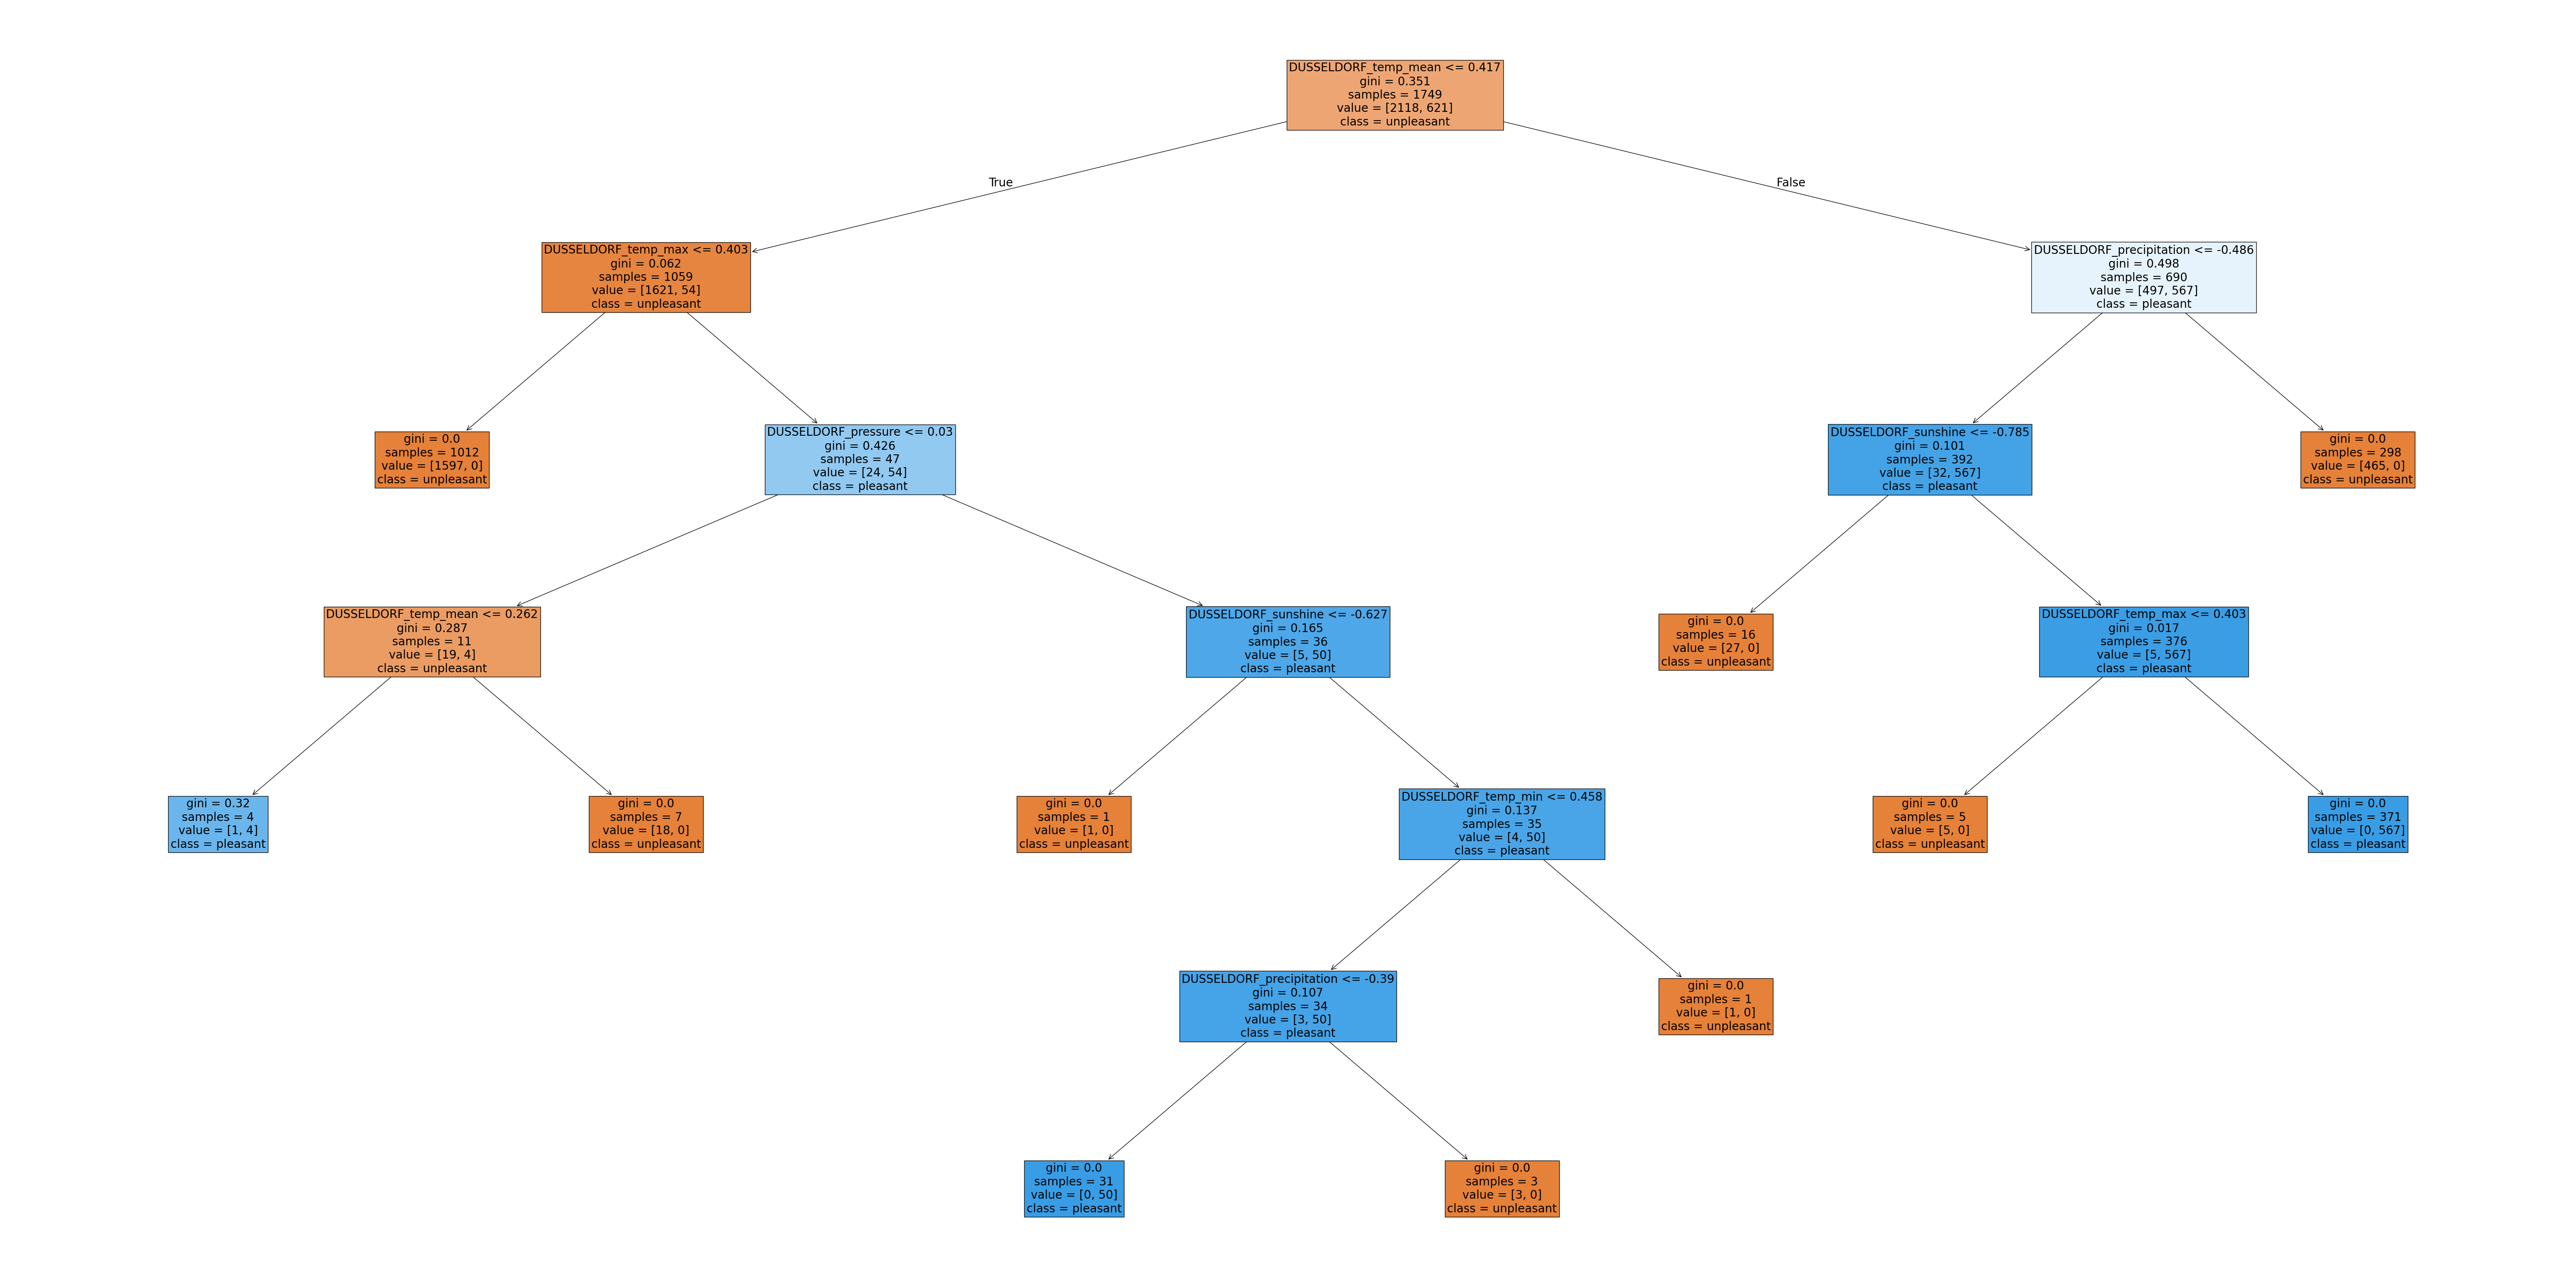

In [40]:
# Plot a tree from the selected random forest
# Class-names = {0:'Unpleasant Weather', 1:'Pleasant Weather'}

fig = plt.figure(figsize=(80,40))
plot_tree(clf3.estimators_[6], fontsize = 20, feature_names = df_dusseldorf.columns, class_names=['unpleasant', 'pleasant'], filled=True);

In [41]:
fig.savefig(os.path.join(path,'Visualizations', 'optimized_random_forest_Dusseldorf.png'),bbox_inches='tight')

## Uncovering Feature Importances

In [42]:
# Retrieve feature importances from the trained model

newarray = clf3.feature_importances_
print(clf3.feature_importances_.shape)
newarray

(9,)


array([0.01133876, 0.0034676 , 0.00642303, 0.02521847, 0.43181227,
       0.06730965, 0.09147293, 0.00088279, 0.36207451])

In [43]:
# Create a list of weather features

wx_list = [feature.replace('DUSSELDORF_', '') for feature in dusseldorf_list]
wx_list

['cloud_cover',
 'humidity',
 'pressure',
 'global_radiation',
 'precipitation',
 'sunshine',
 'temp_mean',
 'temp_min',
 'temp_max']

In [44]:
important = pd.Series(newarray, index = wx_list)
important

cloud_cover         0.011339
humidity            0.003468
pressure            0.006423
global_radiation    0.025218
precipitation       0.431812
sunshine            0.067310
temp_mean           0.091473
temp_min            0.000883
temp_max            0.362075
dtype: float64

['cloud_cover', 'humidity', 'pressure', 'global_radiation', 'precipitation', 'sunshine', 'temp_mean', 'temp_min', 'temp_max']


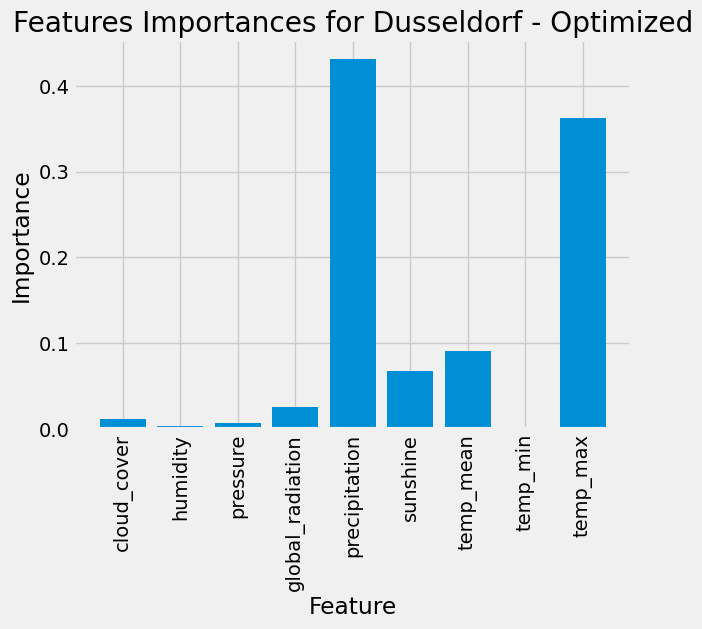

In [45]:
# Plot the results

%matplotlib inline

plt.style.use('fivethirtyeight')
# list of x locations for plotting
x_values = list(range(len(newarray)))
print(wx_list)

plt.bar(x_values, newarray, orientation = 'vertical')
plt.xticks(x_values, wx_list, rotation='vertical')
plt.ylabel('Importance'); plt.xlabel('Feature'); plt.title('Features Importances for Dusseldorf - Optimized');

plt.savefig(os.path.join(path,'dusseldorf_feature_importances_optimized.png'), bbox_inches='tight')
plt.show()